# Recovering Asteroid Rotation Periods from Sparse Light Curves
### Unit 20: Initial Report & Exploratory Data Analysis

**Research question.** Can a supervised machine-learning model accurately recover an
asteroid's rotation period from sparse, irregularly-sampled light-curve data, 
telling the true period apart from the aliases that simpler methods produce, 
reliably enough to be useful on large survey datasets where dedicated follow-up
isn't possible?

**Why it matters.** An asteroid's spin rate constrains its internal structure
(a solid body vs. a gravitationally-bound "rubble pile"), which has both
scientific and planetary-defense value. Surveys like the Rubin Observatory are
about to increase the number of known asteroids several-fold, but each object is
observed only sparsely, too sparse for the classical dense-photometry methods
used to measure rotation. A model that recovers reliable periods from sparse data
turns already-collected observations into usable measurements at no extra cost.

**This notebook (Unit 20)** builds the data foundation and baseline: it loads and
characterizes the data, then sets up the controlled-sparsity experiment and a
non-ML baseline. Additional models and refinement follow in Unit 24.

## Glossary of terms

This project sits at the intersection of asteroid astronomy and machine learning.
The terms below are grouped by theme and defined as they are used here.

### Astronomy: what we are measuring

- **Light curve**: an asteroid's brightness measured over time. As an elongated
  asteroid rotates, it reflects more light when its long side faces us and less
  when it points end-on, so the brightness rises and falls periodically.
- **Rotation period**: how long an asteroid takes to spin once (hours). This is
  the quantity we are ultimately trying to recover; it is the *label* in our data.
- **Amplitude**: the peak-to-peak size of the brightness variation (in
  magnitudes). Larger amplitude ⇒ a more elongated body and, usually, an easier
  period to detect.
- **Magnitude**: the astronomical brightness scale. It is *logarithmic and
  inverted*: smaller magnitude = brighter, and a difference of 1 magnitude is a
  factor of ~2.5 in brightness.
- **Photometry**: the measurement of an object's brightness; a "photometric time
  series" is a light curve.
- **Phase folding / rotational phase**: wrapping all observations modulo the
  rotation period so they map onto a single 0–1 cycle ("phase"). At the *correct*
  period the scattered points collapse into one clean repeating curve (see the
  (9) Metis example); at a wrong period they stay scattered.
- **Double-peaked light curve**: the typical shape of a folded asteroid curve:
  two maxima and two minima per rotation, because an elongated body presents two
  long sides and two short sides per spin.
- **Apparition**: one stretch of time (weeks to months) during which an asteroid
  is well-placed for observation. Data from different apparitions can be years
  apart and cannot be folded together naively.
- **Spin barrier (~2.2 h)**: a critical rotation rate below which a loosely-bound
  body would fly apart under its own centrifugal force. Most asteroids spinning
  faster than this must therefore be small, solid, monolithic rocks.
- **Rubble pile vs. monolith**: an asteroid's internal structure: a gravitational
  aggregate of loose debris ("rubble pile") versus a single coherent rock. The
  rotation period, via the spin barrier, is one of the main clues to which it is.
- **Taxonomic class**: a compositional classification of asteroids from their
  colors/spectra (e.g. **S** = stony, **C** = carbonaceous, **X** = metallic/other).
- **Absolute magnitude (H)**: an asteroid's brightness normalized to standard
  distances; a proxy for size (smaller H ⇒ larger object).

### The core problem: sampling, aliases, and periodograms

- **Dense vs. sparse sampling**: *dense*: many closely-spaced observations that
  trace the light curve in detail (traditional dedicated observing). *Sparse*:
  few, scattered observations (what wide sky surveys produce). Recovering periods
  from sparse data is the whole point of this project.
- **Down-sampling / controlled sparsity**: deliberately deleting most points from
  a dense light curve to simulate sparse survey conditions, while still knowing
  the true period. This lets us measure how performance degrades as data thins out.
- **Alias (aliasing)**: a *false* period that fits the observations nearly as well
  as the true one. Sparse and gappy sampling (especially the once-per-day rhythm of
  ground observing) creates strong aliases; telling the true period from its
  aliases is the classification task at the heart of this project.
- **Periodogram**: a curve of "goodness of fit" (power) versus trial period or
  frequency. Peaks mark candidate periods; the true period and its aliases appear
  as competing peaks.
- **Lomb–Scargle periodogram**: the standard periodogram method for *unevenly*
  sampled data. It is our **baseline**: the classical, non-machine-learning method
  that the model must beat.
- **Cycle-count / extrema ambiguity**: uncertainty over how many rotations elapsed
  between observations, or how many peaks occur per cycle. A common source of
  period errors by an integer factor (e.g. reporting half or double the true value).

### Data sources & fields

- **LCDB** (Asteroid Lightcurve Database): a compilation of published rotation
  periods; our source of ground-truth **labels**.
- **U quality code**: LCDB's reliability rating of a period, on an ordered scale
  from 0 (wrong) to 3 (unambiguous). We keep **U ≥ 2** so labels are trustworthy.
- **ALCDEF** (Asteroid Lightcurve Data Exchange Format): a public archive of the
  actual light-curve measurements; our source of dense curves to down-sample.
- **Session / block**: one continuous observing run (typically one night) of a
  single asteroid, identified by an `LCBLOCKID` in ALCDEF. Each session has its own
  brightness **zero-point**, so sessions must be handled separately.
- **Julian Date (JD)**: a continuous running day-count used as the timestamp for
  each observation (e.g. `2460313.57` = a specific instant); differences in JD are
  simply elapsed days.
- **Zero-point (magnitude offset)**: a constant brightness offset that differs
  between observers/sessions because magnitudes are not all calibrated to a common
  reference. We remove it per session (subtracting each session's median) before
  combining data.
- **ZTF / Gaia DR3**: wide-survey photometry archives (ground-based and
  space-based, respectively) that provide *real* sparse data, used as out-of-sample
  test sets in Unit 24.
- **Rubin Observatory (LSST)**: a new survey that will discover asteroids in
  unprecedented numbers but observe each only sparsely, the motivating use case
  for recovering periods from sparse data.

### Machine-learning terms (as applied here)

- **Label**: the known correct answer used for training; here, the LCDB rotation
  period (or, for classification, whether a candidate period is the true one).
- **Supervised classification (true period vs. alias)**: the primary framing:
  given features of a sparse curve and a candidate period, predict whether that
  candidate is the *true* period or an *alias*.
- **Regression-to-period**: a secondary framing: predict the numeric period
  directly from the curve's features.
- **Baseline model**: a simple reference result (the Lomb–Scargle periodogram, and
  a first simple classifier) that later, more sophisticated models must outperform.
- **Feature**: a single measured property of a light curve fed to the model
  (e.g. number of observations, number of nights, amplitude, strongest periodogram
  peak). Turning raw curves into features is **feature extraction**.

## 1. Data sources & structure

| Source | Role | Structure |
|---|---|---|
| **LCDB** (Asteroid Lightcurve Database) | **Labels**, published rotation periods + quality codes | Fixed-width summary table, one row per asteroid |
| **ALCDEF** (Asteroid Lightcurve Data Exchange Format) | **Dense light curves**, the raw material we down-sample | One file per asteroid; per-session `(JD, magnitude, uncertainty)` blocks |
| ZTF / Gaia DR3 *(planned for final submission)* | Real-world **sparse test sets** | Wide-survey sparse photometry |

The labels come from LCDB filtered to quality code **U ≥ 2** (reliable period
determinations). The light curves come from ALCDEF. An asteroid enters the study
only if it has *both* a reliable period and at least one ALCDEF curve. Loading and
parsing for both sources lives in [`src/data_loading.py`](src/data_loading.py).

## 2. Setup

In [1]:
import sys
from pathlib import Path

# The notebook runs from the repo root; make src/ importable.
sys.path.insert(0, str(Path.cwd() / "src"))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from data_loading import (
    load_lcdb_summary,
    reliable_labels,
    has_alcdef,
    load_alcdef_blocks,
    object_photometry,
    build_coverage_table,
)
from sparsity import (
    prepare_dense_curve,
    downsample,
    sparsity_sweep,
    select_dense_pool,
    phase_fold,
    DEFAULT_SPARSITY_LEVELS,
)
from features import build_feature_table, FEATURE_COLUMNS

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 30)

# A consistent, readable plotting style for the whole notebook.
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
BLUE, GREEN, RED, PURPLE, ORANGE = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#DD8452"

FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

## 3. The labels (LCDB)

Our labels are the published rotation periods in the LCDB, but not every published
period is hight quality, so we keep only the reliable ones. The LCDB attaches a
**quality code U** to every period: the compilers' own assessment of how secure that
determination is, on an ordered scale from 0 to 3 (with half-steps such as `2-` and
`2+`):

- **U = 3**: unambiguous: a unique, securely determined period with essentially full
  rotational coverage.
- **U = 2**: reasonably reliable, but the value can still be off by roughly ~30%
  from incomplete coverage, or by an integer factor when the number of cycles or
  extrema per cycle is uncertain.
- **U = 1**: may well be wrong; what looks like rotational variation could be noise
  or calibration error.
- **U = 0**: a period since shown to be incorrect.

These periods are the **ground truth the model learns from**. In
supervised learning the model is only as good as its labels, training or scoring
against wrong periods would teach and reward the model for the wrong answers. 
We therefore keep only **U ≥ 2** (also the
LCDB's own stated minimum for statistical work) together with a numeric period.
`reliable_labels` applies this filter, encoding the half-step code as an ordered
number (`parse_u_code`) so it can be compared and plotted; Section 3.2 shows how much
data the cut discards.

In [2]:
lcdb = load_lcdb_summary()
labels = reliable_labels(lcdb, min_u=2.0)

print(f"LCDB summary rows (all):           {len(lcdb):>7,}")
print(f"Reliable labels (U>=2, has period):{len(labels):>7,}")

labels[["number", "name", "class", "period_h", "amp_max", "U", "diam_km", "H"]].head(8)

LCDB summary rows (all):            36,259
Reliable labels (U>=2, has period): 29,729


,number,name,class,period_h,amp_max,U,diam_km,H
0,1.0,Ceres,C,9.07417,0.06,3,939.40,3.53
1,2.0,Pallas,B,7.81320,0.16,3,512.22,4.13
2,3.0,Juno,S,7.21000,0.22,3,257.88,5.28
3,4.0,Vesta,V,5.34200,0.19,3,525.00,3.20
4,5.0,Astraea,S,16.80600,0.27,3,115.00,6.85
5,6.0,Hebe,S,7.27450,0.21,3,183.41,5.60
6,7.0,Iris,S,7.13900,0.37,3,198.97,5.60
7,8.0,Flora,S,12.86500,0.11,3,138.79,6.56


### 3.1 Period and amplitude distributions

Rotation period spans several orders of magnitude, so it is shown on a log scale.
The dashed line marks the **~2.2 h "spin barrier"**, below it, a
strengthless rubble pile would fly apart, so faster rotators are (mostly) small
monolithic bodies. Amplitude (peak-to-peak brightness variation) is a proxy for
shape elongation and for how easy a period is to recover.

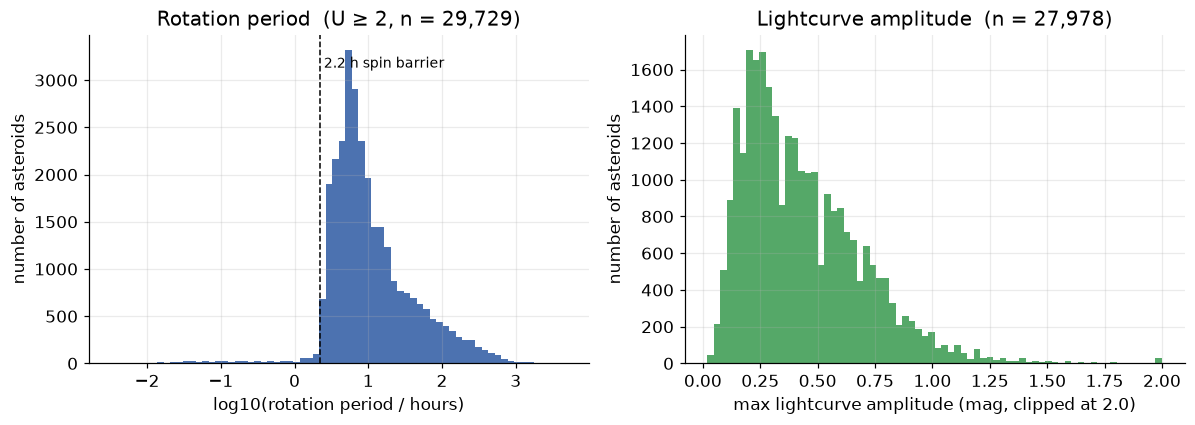

Period (hours) summary:
min       0.003
25%       4.770
50%       7.867
75%      19.862
max    4812.000


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

p = labels["period_h"].dropna()
p = p[p > 0]
axes[0].hist(np.log10(p), bins=70, color=BLUE)
axes[0].axvline(np.log10(2.2), ls="--", color="k", lw=1)
axes[0].text(np.log10(2.2), axes[0].get_ylim()[1]*0.9, " 2.2 h spin barrier", fontsize=9)
axes[0].set_xlabel("log10(rotation period / hours)")
axes[0].set_ylabel("number of asteroids")
axes[0].set_title(f"Rotation period  (U ≥ 2, n = {len(p):,})")

a = labels["amp_max"].dropna()
a = a[a > 0]
axes[1].hist(a.clip(upper=2.0), bins=70, color=GREEN)
axes[1].set_xlabel("max lightcurve amplitude (mag, clipped at 2.0)")
axes[1].set_ylabel("number of asteroids")
axes[1].set_title(f"Lightcurve amplitude  (n = {len(a):,})")

fig.tight_layout()
fig.savefig(FIGDIR / "labels_period_amplitude.png", bbox_inches="tight")
plt.show()

print("Period (hours) summary:")
print(p.describe()[["min", "25%", "50%", "75%", "max"]].round(3).to_string())

### 3.2 Quality codes and taxonomic classes

The U-code distribution shows how much data we discard by requiring U ≥ 2, and the
taxonomic-class mix tells us which asteroid types dominate the labels.

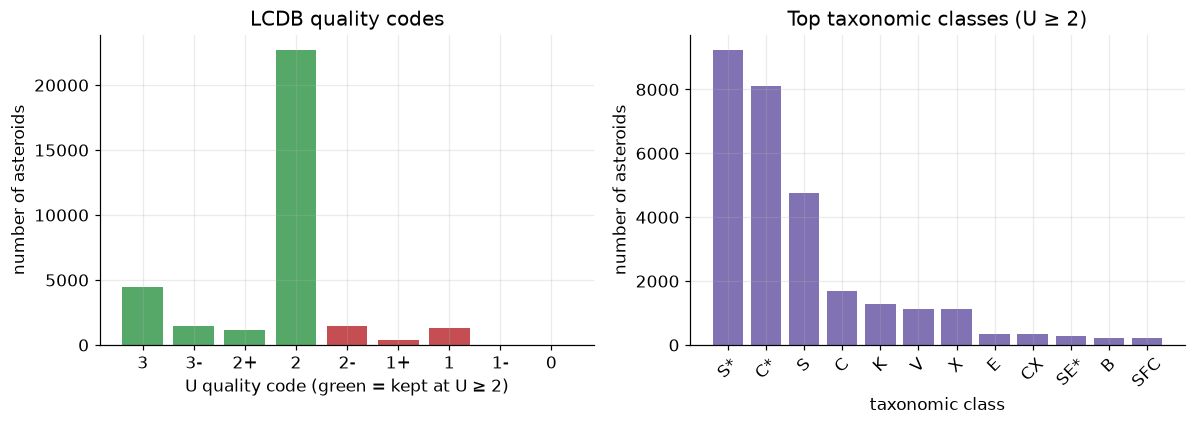

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

u_order = ["3", "3-", "2+", "2", "2-", "1+", "1", "1-", "0"]
u_counts = lcdb["U"].value_counts().reindex(u_order).fillna(0)
colors = [GREEN if u in {"3", "3-", "2+", "2"} else RED for u in u_order]
axes[0].bar(u_order, u_counts.values, color=colors)
axes[0].set_xlabel("U quality code (green = kept at U ≥ 2)")
axes[0].set_ylabel("number of asteroids")
axes[0].set_title("LCDB quality codes")

top_classes = (labels["class"].replace("", np.nan).dropna()
               .value_counts().head(12))
axes[1].bar(top_classes.index, top_classes.values, color=PURPLE)
axes[1].set_xlabel("taxonomic class")
axes[1].set_ylabel("number of asteroids")
axes[1].set_title("Top taxonomic classes (U ≥ 2)")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(FIGDIR / "labels_quality_class.png", bbox_inches="tight")
plt.show()

### 3.3 Amplitude across taxonomic classes

A categorical-vs-continuous view: how lightcurve
amplitude (a proxy for how elongated a body is) varies across the main
taxonomic classes.

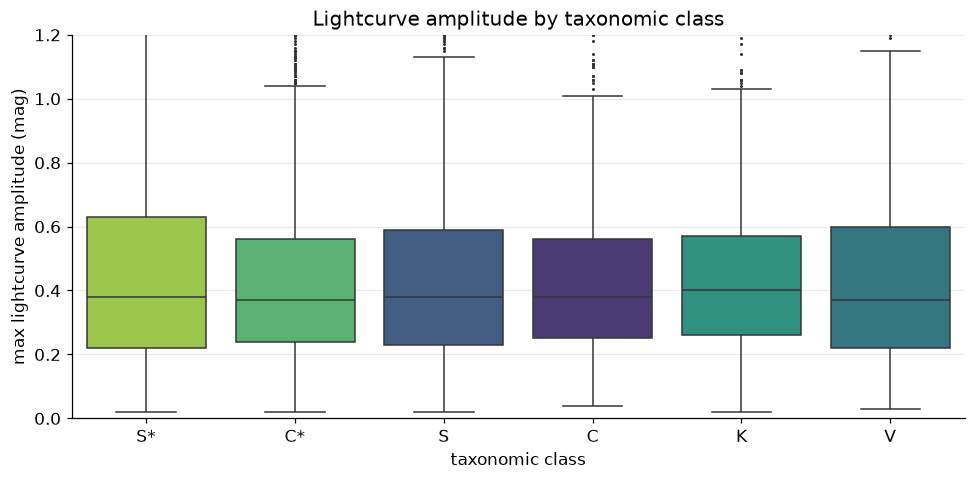

In [5]:
top_cls = labels["class"].replace("", np.nan).dropna().value_counts().head(6).index
sub = labels[labels["class"].isin(top_cls) & labels["amp_max"].notna()]

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=sub, x="class", y="amp_max", order=list(top_cls),
            hue="class", palette="viridis", legend=False, fliersize=1, ax=ax)
ax.set_ylim(0, 1.2)
ax.set_xlabel("taxonomic class")
ax.set_ylabel("max lightcurve amplitude (mag)")
ax.set_title("Lightcurve amplitude by taxonomic class")
fig.tight_layout()
fig.savefig(FIGDIR / "amplitude_by_class.png", bbox_inches="tight")
plt.show()

## 4. Data cleaning & quality control

Cleaning happens at two levels, the **labels** (LCDB) and the **light curves**
(ALCDEF), and is applied inside the loader/pipeline functions so it runs
identically everywhere it is used.

**Labels (LCDB).** Numeric fields are stored as strings in the source (to preserve
precision), so they are translated to numbers, with non-numeric entries becoming
missing. Rows without a reliable period are then removed: we require quality code
**U ≥ 2** *and* a numeric period. A couple of thousand rows are *unnumbered* objects
(comets and provisional designations with no MPC number, stored under the
placeholder "0"); they are valid for the population statistics but cannot be
uniquely keyed to an ALCDEF light curve, so they drop out of the modeling dataset
(Section 6). Among genuinely numbered asteroids there are **no duplicates** — each
appears exactly once (verified below).

**Light curves (ALCDEF).** Each curve is calibrated by removing every session's
magnitude zero-point, and **outliers are rejected** with a 5 × median-absolute-
deviation cut (`prepare_dense_curve`, used from Section 8 on). Malformed `DATA`
rows are skipped during parsing.

**Imputation.** The only imputed value is the periodogram false-alarm probability,
which is undefined for a few sparse curves; it is set to the
maximally-unreliable value (1.0) before modelling (Section 10).

**Feature engineering.** Every model input is engineered from the raw curves — the
sparsity sweep (Section 8) and the 14-feature periodogram/curve vector (Section 10).

In [6]:
key_cols = ["number", "name", "class", "period_h", "amp_max", "U_num", "diam_km", "H"]
missing = lcdb[key_cols].isna().sum()
print(f"Missing values in key LCDB columns (of {len(lcdb):,} rows):")
print(missing.to_string())

n_unnumbered = int(lcdb["number"].isna().sum())
dupes = int(lcdb["number"].dropna().duplicated().sum())
print(f"\nUnnumbered objects (comets / provisional desigs, no MPC number): {n_unnumbered:,}")
print(f"Duplicate numbers among numbered asteroids: {dupes}")

n_all = len(lcdb)
n_with_period = int(lcdb["period_h"].notna().sum())
print("\nReliability filter (removal of missing / low-quality periods):")
print(f"  {n_all:,} summary rows")
print(f"  {n_with_period:,} have a numeric period")
print(f"  {len(labels):,} are reliable (U >= 2 AND period present)  <- kept as labels")
print(f"  {n_all - len(labels):,} dropped")

Missing values in key LCDB columns (of 36,259 rows):
number      1966
name           0
class         27
period_h    1504
amp_max     3709
U_num       3362
diam_km       26
H             25

Unnumbered objects (comets / provisional desigs, no MPC number): 1,966
Duplicate numbers among numbered asteroids: 0

Reliability filter (removal of missing / low-quality periods):
  36,259 summary rows
  34,755 have a numeric period
  29,729 are reliable (U >= 2 AND period present)  <- kept as labels
  6,530 dropped


## 5. The light curves (ALCDEF)

Each ALCDEF file is a set of observing **sessions** (blocks), each a run of
`(JD, magnitude, uncertainty)` points from one night. Crucially, magnitudes are
**not** reduced to a common zero-point, each session has its own offset, so
sessions must be treated separately rather than concatenated blindly.

To characterize coverage across the whole dataset we precompute a per-object
**coverage table** with one pass over the archive (cached under `data/interim/`;
the cell rebuilds it from the raw zip if the cache is absent). Each row is one
asteroid, summarised by these fields:

| Field | What it measures | Why it matters here |
|---|---|---|
| `n_sessions` | number of separate observing runs (blocks), typically one night each | more sessions = more independent looks at the rotation |
| `n_points` | total brightness measurements, summed over all sessions | the raw amount of data available to thin down |
| `n_nights` | distinct calendar nights observed (distinct integer Julian dates) | separates "many points on a few nights" from genuinely spread-out sampling |
| `jd_span_days` | elapsed time from the first to the last observation, in days | a long span can mean several apparitions years apart, which complicates period finding |
| `max_session_points` | number of points in the single best-sampled session | bounds how well any one night traces the rotation curve; the "dense" cut in Section 6 keys on it |
| `n_bands` | number of distinct photometric filters used (e.g. R, V, Sloan g/r) | extra bands add extra per-band zero-points that must be reconciled |

The `describe()` below gives the distribution of each field across all objects; the
plots in Section 5.1 then show their full shapes.

In [7]:
COV_PATH = Path("data/interim/coverage_summary.parquet")

if COV_PATH.exists():
    cov = pd.read_parquet(COV_PATH)
else:
    nums = sorted(int(n) for n in labels["number"].dropna() if has_alcdef(int(n)))
    cov = build_coverage_table(nums)
    COV_PATH.parent.mkdir(parents=True, exist_ok=True)
    cov.to_parquet(COV_PATH, index=False)

print(f"objects with a coverage summary: {len(cov):,}")
cov[["number", "n_sessions", "n_points", "n_nights",
     "jd_span_days", "max_session_points", "n_bands"]].describe().round(2)

objects with a coverage summary: 20,501


,number,n_sessions,n_points,n_nights,jd_span_days,max_session_points,n_bands
count,20501.00,20501.00,20501.00,20501.00,20501.00,20501.00,20501.00
mean,81340.62,17.43,499.08,17.41,431.74,52.03,1.17
std,97004.37,11.01,815.77,10.81,1149.23,76.10,0.46
min,1.00,1.00,2.00,1.00,0.02,2.00,1.00
25%,12919.00,10.00,63.00,10.00,13.56,11.00,1.00
50%,46449.00,16.00,304.00,16.00,25.54,46.00,1.00
75%,112740.00,24.00,724.00,24.00,91.90,47.00,1.00
max,612050.00,189.00,23583.00,184.00,11953.88,1417.00,6.00


### 5.1 How much data does a typical object actually have?

These distributions are the single most important input to the down-sampling
design: they tell us how dense the "dense" ALCDEF curves really are before we
start throwing observations away.

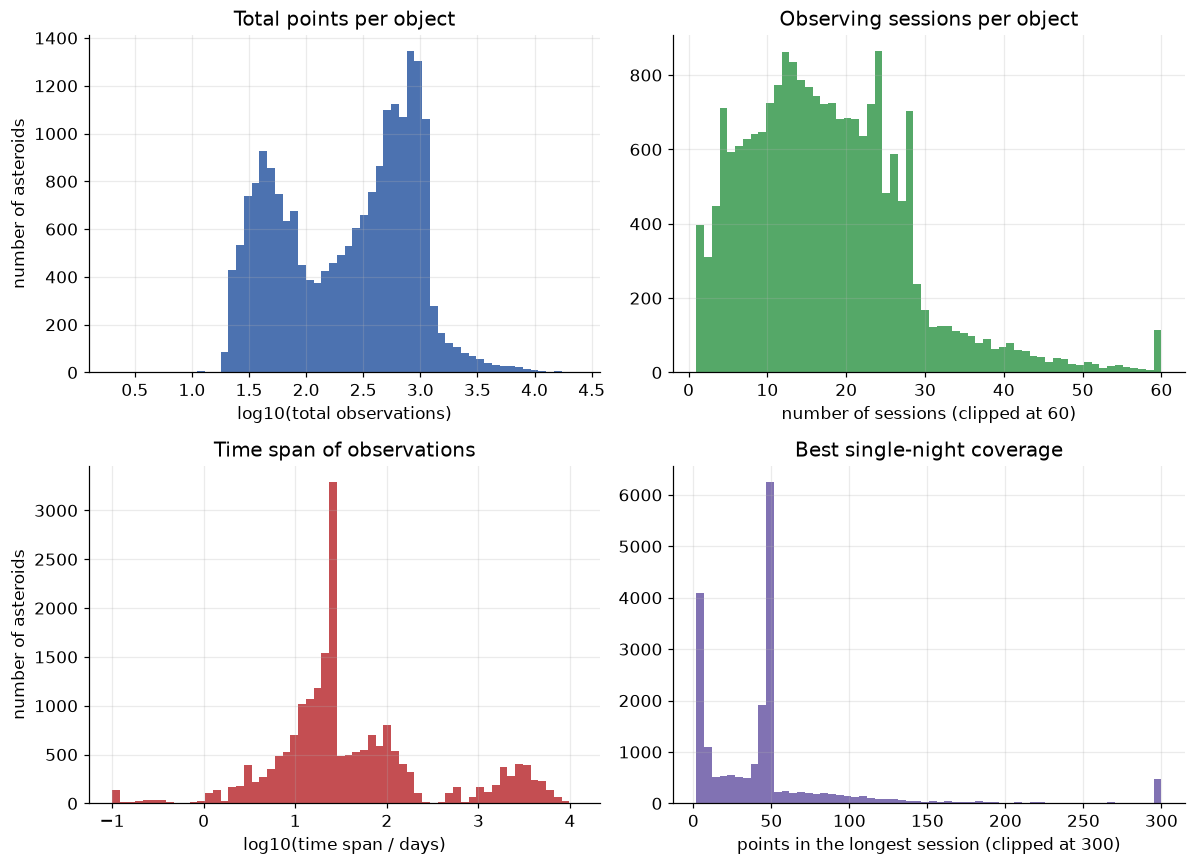

Total points per object — 25th/50th/75th pct: 63 / 304 / 724
Objects with < 50 total observations: 19.5%


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(np.log10(cov["n_points"].clip(lower=1)), bins=60, color=BLUE)
axes[0, 0].set_xlabel("log10(total observations)")
axes[0, 0].set_ylabel("number of asteroids")
axes[0, 0].set_title("Total points per object")

axes[0, 1].hist(cov["n_sessions"].clip(upper=60), bins=60, color=GREEN)
axes[0, 1].set_xlabel("number of sessions (clipped at 60)")
axes[0, 1].set_title("Observing sessions per object")

axes[1, 0].hist(np.log10(cov["jd_span_days"].clip(lower=0.1)), bins=60, color=RED)
axes[1, 0].set_xlabel("log10(time span / days)")
axes[1, 0].set_ylabel("number of asteroids")
axes[1, 0].set_title("Time span of observations")

axes[1, 1].hist(cov["max_session_points"].clip(upper=300), bins=60, color=PURPLE)
axes[1, 1].set_xlabel("points in the longest session (clipped at 300)")
axes[1, 1].set_title("Best single-night coverage")

fig.tight_layout()
fig.savefig(FIGDIR / "coverage_distributions.png", bbox_inches="tight")
plt.show()

q = cov["n_points"].quantile([0.25, 0.5, 0.75]).astype(int)
print(f"Total points per object — 25th/50th/75th pct: {q.iloc[0]} / {q.iloc[1]} / {q.iloc[2]}")
sparse = (cov["n_points"] < 50).mean() * 100
print(f"Objects with < 50 total observations: {sparse:.1f}%")

## 6. The modeling dataset (labels ⋈ curves)

Joining reliable labels to coverage on the asteroid number gives the set of
objects usable for supervised learning: each has a trustworthy period *and* a
light curve to (down-)sample.

In [9]:
data = labels.merge(cov, on="number", how="inner")
print(f"Modeling dataset (labeled AND has curve): {len(data):,} asteroids")

data[["number", "name", "class", "period_h", "amp_max", "U",
      "n_sessions", "n_points", "n_nights", "max_session_points"]].head(10)

Modeling dataset (labeled AND has curve): 20,501 asteroids


,number,name,class,period_h,amp_max,U,n_sessions,n_points,n_nights,max_session_points
0,1.0,Ceres,C,9.07417,0.06,3,5,1210,5,465
1,3.0,Juno,S,7.21000,0.22,3,18,1523,18,260
2,4.0,Vesta,V,5.34200,0.19,3,29,3382,39,357
3,6.0,Hebe,S,7.27450,0.21,3,9,388,9,47
4,7.0,Iris,S,7.13900,0.37,3,29,1999,29,355
5,8.0,Flora,S,12.86500,0.11,3,8,2164,14,318
6,9.0,Metis,S,5.07900,0.32,3,4,2957,4,892
7,10.0,Hygiea,C,13.82800,0.27,3,18,12153,16,1325
8,11.0,Parthenope,S,13.72040,0.12,3,85,21725,93,463
9,12.0,Victoria,L,8.65990,0.42,3,11,3017,15,369


### 6.1 Not every labeled curve is "dense"

The proposal's premise is to take *dense* curves and down-sample them. But the
coverage EDA shows a large fraction of objects are already sparse. The table below
counts how many objects clear increasingly strict density thresholds — this
defines the pool of genuinely dense curves available as down-sampling sources.

In [10]:
thresholds = [
    ("any curve", data["n_points"] >= 1),
    ("≥ 50 total points", data["n_points"] >= 50),
    ("≥ 100 total points", data["n_points"] >= 100),
    ("≥ 30 points in one session", data["max_session_points"] >= 30),
    ("dense: ≥100 pts AND a ≥30-pt session", (data["n_points"] >= 100) & (data["max_session_points"] >= 30)),
]
summary = pd.DataFrame(
    [(name, int(mask.sum()), f"{mask.mean()*100:.1f}%") for name, mask in thresholds],
    columns=["density threshold", "n asteroids", "share of dataset"],
)
summary

,density threshold,n asteroids,share of dataset
0,any curve,20501,100.0%
1,≥ 50 total points,16507,80.5%
2,≥ 100 total points,13620,66.4%
3,≥ 30 points in one session,13407,65.4%
4,dense: ≥100 pts AND a ≥30-pt session,12785,62.4%


## 7. What a light curve looks like

To make the problem concrete, we plot one well-sampled asteroid: its raw
multi-session photometry (each session in its own color, showing the per-session
zero-point offsets) and its **phase-folded** curve at the known LCDB period. When
folded at the true period, the points collapse onto the characteristic
double-peaked rotation curve — the signal the model must learn to recover from far
fewer points.

Example: (9) Metis   P = 5.079 h,  U = 3,  amp_max = 0.32 mag,  span = 7.1 d


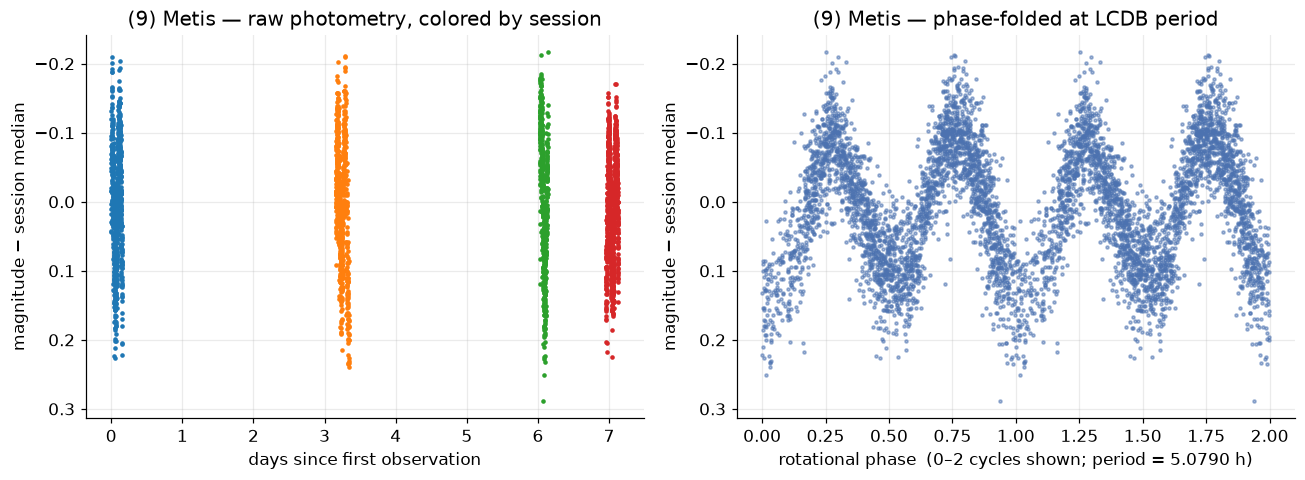

In [11]:
# Pick a densely-sampled fast rotator observed within a *single apparition*
# (short total time span) so the fold stays coherent: folding data taken decades
# apart at a synodic period smears across tens of thousands of cycles.
sel = data[(data["period_h"].between(2.5, 9))
           & (data["amp_max"] >= 0.3)
           & (data["max_session_points"] >= 150)
           & (data["jd_span_days"] <= 30)
           & (data["n_sessions"] >= 3)].sort_values("n_points", ascending=False)
if sel.empty:  # relax if the strict filter finds nothing
    sel = data[(data["period_h"].between(2.5, 9))
               & (data["amp_max"] >= 0.3)
               & (data["jd_span_days"] <= 60)].sort_values("n_points", ascending=False)
row = sel.iloc[0]
num, name, P = int(row["number"]), row["name"], float(row["period_h"])
print(f"Example: ({num}) {name}   P = {P} h,  U = {row['U']},  amp_max = {row['amp_max']} mag,"
      f"  span = {row['jd_span_days']:.1f} d")

phot = object_photometry(num).copy()
# Align each session's zero-point by subtracting its median magnitude.
phot["mag_adj"] = phot["mag"] - phot.groupby("block_id")["mag"].transform("median")
# Robust outlier rejection (median absolute deviation) to drop bad points.
med = phot["mag_adj"].median()
mad = 1.4826 * (phot["mag_adj"] - med).abs().median()
phot = phot[(phot["mag_adj"] - med).abs() < 5 * mad]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for bid, g in phot.groupby("block_id"):
    axes[0].plot(g["jd"] - phot["jd"].min(), g["mag_adj"], ".", ms=4)
axes[0].invert_yaxis()
axes[0].set_xlabel("days since first observation")
axes[0].set_ylabel("magnitude − session median")
axes[0].set_title(f"({num}) {name} — raw photometry, colored by session")

phase = ((phot["jd"] * 24.0) % P) / P
axes[1].plot(phase, phot["mag_adj"], ".", ms=4, color=BLUE, alpha=0.5)
axes[1].plot(phase + 1, phot["mag_adj"], ".", ms=4, color=BLUE, alpha=0.5)  # repeat for continuity
axes[1].invert_yaxis()
axes[1].set_xlabel("rotational phase  (0–2 cycles shown; period = %.4f h)" % P)
axes[1].set_ylabel("magnitude − session median")
axes[1].set_title(f"({num}) {name} — phase-folded at LCDB period")

fig.tight_layout()
fig.savefig(FIGDIR / "example_lightcurve.png", bbox_inches="tight")
plt.show()

## 8. The controlled-sparsity pipeline

This is the experimental core of the project. We take a *dense* light curve with
a known period and progressively delete observations to simulate what a wide
survey would have seen — then, in the baseline and models that follow, we test how
well the period can still be recovered at each level of sparsity.

**Source pool.** Only genuinely dense curves make good sources, so we down-sample
from the dense pool defined in Section 6.1 (≥ 100 total points and at least one
≥ 30-point session).

**Preparation.** For each object, `prepare_dense_curve` concatenates all sessions,
removes each session's magnitude zero-point (so the curve sits on one consistent
photometric system, like calibrated survey data), and rejects outliers.

**Down-sampling.** `sparsity_sweep` draws subsets of decreasing size
(default 200, 100, 50, 30, 20, 10, 5 observations). The default **stratified**
strategy spreads the kept points across distinct observing nights, mimicking how
survey epochs are spread over time rather than clustered in one session.

Dense source pool: 12,785 asteroids


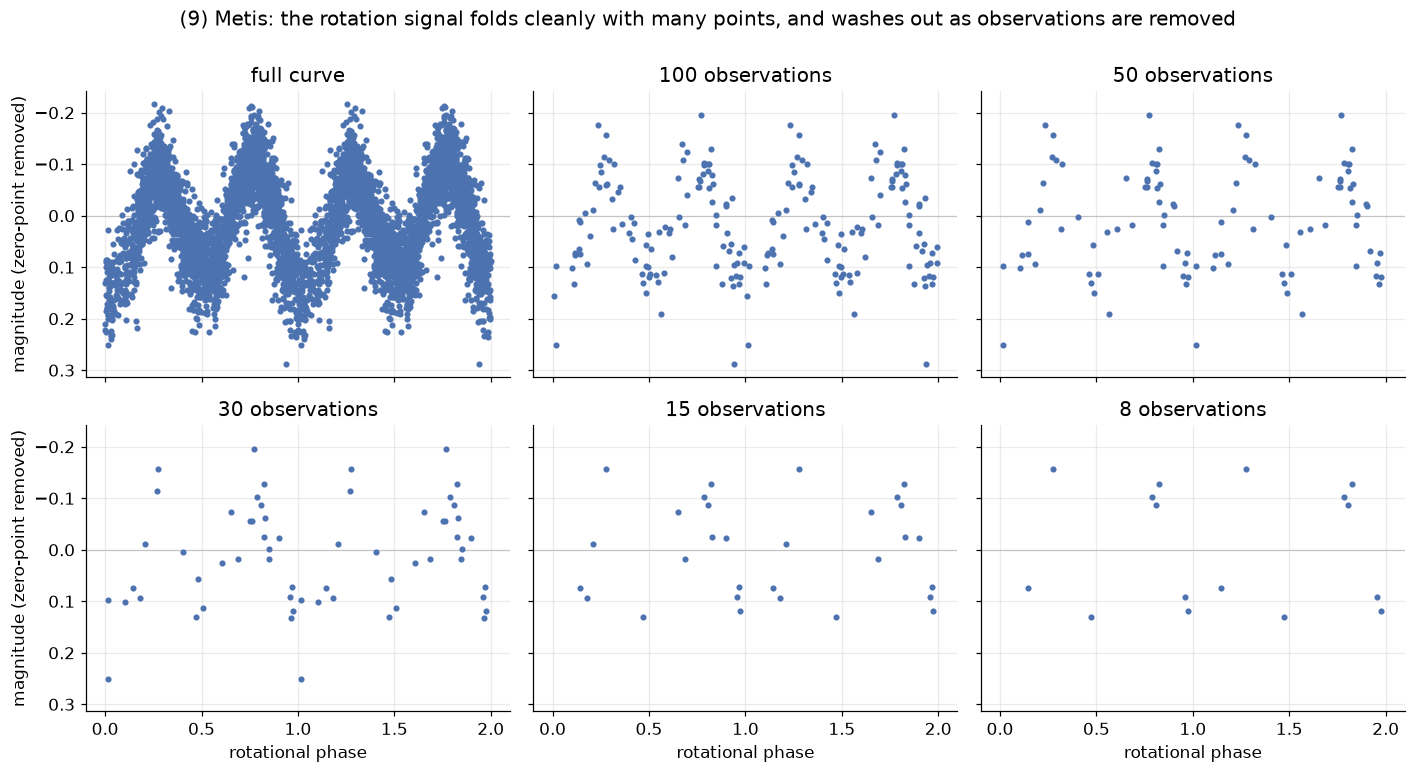

In [12]:
dense_pool = select_dense_pool(cov, min_points=100, min_session_points=30)
print(f"Dense source pool: {len(dense_pool):,} asteroids")

# Demonstrate on the same example object (9 Metis), folded at its true period.
curve = prepare_dense_curve(num)
demo_levels = [len(curve), 100, 50, 30, 15, 8]
demo = {n: (curve if n >= len(curve) else downsample(curve, n, rng=0))
        for n in demo_levels}

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for ax, n in zip(axes.ravel(), demo_levels):
    sub = demo[n]
    ph = phase_fold(sub["jd"].values, P)
    ax.plot(ph, sub["mag"], ".", ms=6, color=BLUE)
    ax.plot(ph + 1, sub["mag"], ".", ms=6, color=BLUE)  # repeat second cycle
    label = "full curve" if n >= len(curve) else f"{len(sub)} observations"
    ax.set_title(label)
    ax.axhline(0, color="0.8", lw=0.8, zorder=0)
for ax in axes[:, 0]:
    ax.set_ylabel("magnitude (zero-point removed)")
for ax in axes[1, :]:
    ax.set_xlabel("rotational phase")
axes[0, 0].invert_yaxis()  # shared axes -> inverts all
fig.suptitle(f"({num}) {name}: the rotation signal folds cleanly with many points, "
             f"and washes out as observations are removed", y=1.0)
fig.tight_layout()
fig.savefig(FIGDIR / "sparsity_demo.png", bbox_inches="tight")
plt.show()

Folded at the *true* period, the double-peaked shape is obvious with hundreds of
points and still discernible down to a few dozen, but by ~10–15 observations it is
barely distinguishable from noise. That is precisely the regime where the
classical periodogram starts returning aliases instead of the true period — and
where a model that has learned what real rotation signals look like may still
succeed. Quantifying exactly where that breakdown happens, and beating it, is the
goal of the baseline and models that follow.

## 9. The Lomb–Scargle baseline

The Lomb–Scargle periodogram is the standard way to find a periodic signal in
unevenly-sampled data. It is the **non-ML reference this project must beat**: for
each down-sampled curve we take the periodogram's strongest peak as the estimated
period and ask whether it matches the true LCDB period.

Three modelling choices make this a fair, honest baseline (see
[`src/baseline.py`](src/baseline.py)):

- **Half-period aliases count as success.** Asteroid curves are double-peaked, so
  Lomb–Scargle most often returns *half* the true rotation period. An estimate is
  scored correct if it matches the true period or its 2× / 0.5× harmonic within 5%.
- **Bounded, controlled experiment.** We search periods of 1–48 h and evaluate on
  objects whose true period is 2–24 h; each object is reduced to its densest single
  apparition so the time baseline is controlled and the sweep isolates the effect
  of the *number* of observations.
- **Unweighted periodogram.** ALCDEF's per-observer error estimates are
  heterogeneous and, empirically, weighting by them drags the top peak onto
  aliases — as the (9) Metis check below shows — so we run Lomb–Scargle unweighted.

In [13]:
from baseline import lombscargle_best, period_matches, run_baseline
from baseline import EVAL_MIN_PERIOD_H, EVAL_MAX_PERIOD_H
from sparsity import densest_apparition

# Why unweighted: the same dense curve, scored both ways.
mc = densest_apparition(prepare_dense_curve(9))
for use_err in (False, True):
    r = lombscargle_best(mc["jd"].values, mc["mag"].values, mc["mag_err"].values,
                         use_errors=use_err)
    ok = period_matches(r["best_period_h"], 5.079)
    tag = "weighted by errors" if use_err else "unweighted"
    print(f"(9) Metis, {tag:>18}: LS period = {r['best_period_h']:.3f} h  "
          f"(true 5.079 h, 2x alias) -> {'RECOVERED' if ok else 'missed (alias)'}")

(9) Metis,         unweighted: LS period = 2.540 h  (true 5.079 h, 2x alias) -> RECOVERED
(9) Metis, weighted by errors: LS period = 2.295 h  (true 5.079 h, 2x alias) -> missed (alias)


In [14]:
# Load the cached baseline sweep (1,500 sampled asteroids x 7 sparsity levels).
# If the cache is absent, recompute on a smaller sample so the notebook is runnable.
BASE_PATH = Path("data/interim/baseline_results.parquet")
if BASE_PATH.exists():
    base = pd.read_parquet(BASE_PATH)
else:
    elig = data[data["period_h"].between(EVAL_MIN_PERIOD_H, EVAL_MAX_PERIOD_H)]
    lookup = dict(zip(elig["number"].astype(int), elig["period_h"]))
    rng = np.random.default_rng(20260722)
    sample = sorted(int(x) for x in rng.choice(list(lookup), size=400, replace=False))
    base = run_baseline(sample, lookup, seed=0).merge(
        data.set_index("number")[["amp_max", "class"]],
        left_on="number", right_index=True, how="left")

print(f"Baseline over {base['number'].nunique():,} asteroids "
      f"({len(base):,} object x sparsity-level trials)")

Baseline over 1,500 asteroids (10,500 object x sparsity-level trials)


### 9.1 How period recovery degrades with sparsity

This is the central Unit 20 result: the fraction of asteroids whose period the
periodogram recovers, as a function of how many observations remain.

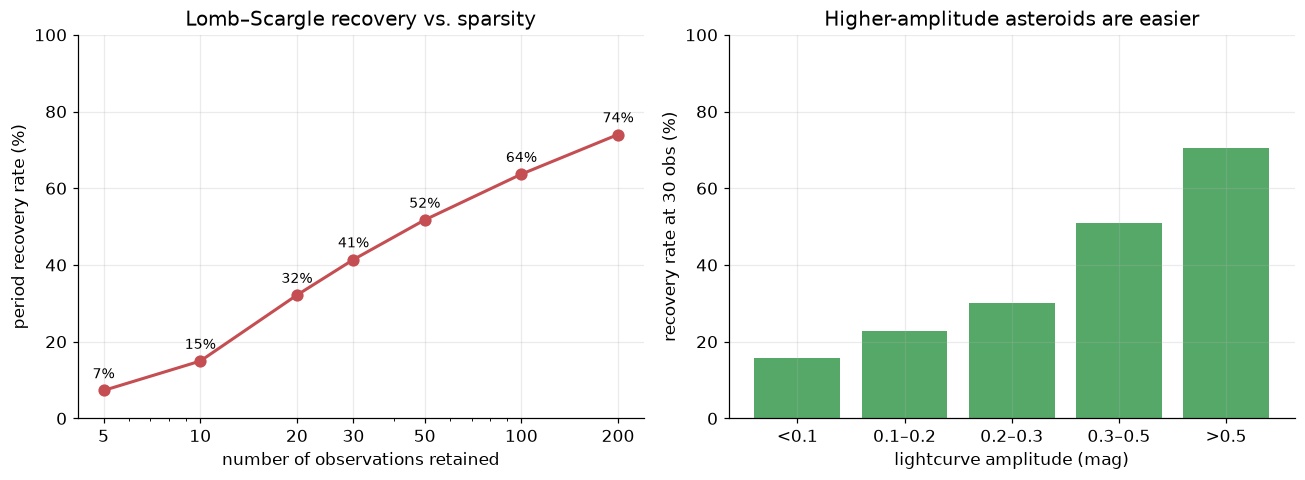

Recovery rate by number of observations:
level
5       7.3 %
10     14.9 %
20     32.1 %
30     41.4 %
50     51.7 %
100    63.7 %
200    74.0 %


In [15]:
levels = [5, 10, 20, 30, 50, 100, 200]
rec = base.groupby("level")["matched"].mean().reindex(levels) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(rec.index, rec.values, "o-", color=RED, lw=2, ms=7)
axes[0].set_xscale("log")
axes[0].set_xticks(levels)
axes[0].set_xticklabels(levels)
axes[0].set_xlabel("number of observations retained")
axes[0].set_ylabel("period recovery rate (%)")
axes[0].set_ylim(0, 100)
axes[0].set_title("Lomb–Scargle recovery vs. sparsity")
for x, y in zip(rec.index, rec.values):
    axes[0].annotate(f"{y:.0f}%", (x, y), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=9)

# Which asteroids are easier? Recovery vs amplitude at a fixed sparse level.
level_fixed = 30
sub = base[base["level"] == level_fixed].copy()
sub["amp_bin"] = pd.cut(sub["amp_max"], [0, 0.1, 0.2, 0.3, 0.5, 5.0],
                        labels=["<0.1", "0.1–0.2", "0.2–0.3", "0.3–0.5", ">0.5"])
rec_amp = sub.groupby("amp_bin", observed=True)["matched"].mean() * 100
axes[1].bar(range(len(rec_amp)), rec_amp.values, color=GREEN)
axes[1].set_xticks(range(len(rec_amp)))
axes[1].set_xticklabels(rec_amp.index)
axes[1].set_xlabel("lightcurve amplitude (mag)")
axes[1].set_ylabel(f"recovery rate at {level_fixed} obs (%)")
axes[1].set_ylim(0, 100)
axes[1].set_title("Higher-amplitude asteroids are easier")

fig.tight_layout()
fig.savefig(FIGDIR / "baseline_recovery.png", bbox_inches="tight")
plt.show()

print("Recovery rate by number of observations:")
print((rec.round(1).astype(str) + " %").to_string())

The baseline behaves exactly as expected: reliable with a few hundred points,
degrading steadily as observations are removed, and collapsing in the sparse
regime (below ~20–30 observations) that wide surveys actually deliver. It is also
strongly amplitude-dependent — elongated, high-amplitude asteroids stay
recoverable far longer than round, low-amplitude ones.

**This is the number to beat.** In the sparse regime the periodogram alone fails
on most objects; the supervised model's job is to do better there — using not just
the single top peak but the full shape of the periodogram and curve. That
model, and the features it needs, is the next step.

## 10. Baseline machine-learning model: is this period reliable?

Lomb–Scargle returns a period for every object but cannot say which to trust — in
the sparse regime most are aliases. The supervised model's job is exactly that
judgement: **given features of a sparse curve and its periodogram, predict whether
the Lomb–Scargle period is correct.** This is the "true period vs. alias"
framing from the proposal, and it is how the model beats the baseline — not by
finding new periods, but by turning a low-purity catalog into a high-purity one,
flagging the objects whose periods can be believed.

For each of ~2,000 asteroids at all seven sparsity levels we extract the feature
vector from [`src/features.py`](src/features.py) — sampling geometry, photometric
amplitude/scatter, and periodogram shape (top-peak power, peak dominance,
false-alarm probability, number of competing peaks, daily-alias distance) — and
label it with whether the Lomb–Scargle period was correct.

In [16]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

FEAT_PATH = Path("data/processed/features.parquet")
if FEAT_PATH.exists():
    feat = pd.read_parquet(FEAT_PATH)
else:  # fallback: build a smaller table so the notebook is self-contained
    elig = data[data["period_h"].between(EVAL_MIN_PERIOD_H, EVAL_MAX_PERIOD_H)]
    lookup = dict(zip(elig["number"].astype(int), elig["period_h"]))
    rng = np.random.default_rng(424242)
    smp = sorted(int(x) for x in rng.choice(list(lookup), size=500, replace=False))
    feat = build_feature_table(smp, lookup, seed=0).merge(
        data.set_index("number")[["amp_max", "class"]],
        left_on="number", right_index=True, how="left")

X = feat[FEATURE_COLUMNS].copy()
X["ls_fap"] = X["ls_fap"].fillna(1.0)   # NaN FAP -> maximally unreliable
X = X.fillna(0.0)
y = feat["matched"].astype(int).values
groups = feat["number"].values

# Split by ASTEROID, not by row: the same object at different sparsity levels must
# not straddle train/test, or the model would be scored on objects it has seen.
train, test = next(GroupShuffleSplit(n_splits=1, test_size=0.3,
                                     random_state=0).split(X, y, groups))
Xtr, Xte, ytr, yte = X.iloc[train], X.iloc[test], y[train], y[test]
print(f"{len(feat):,} rows | train {len(Xtr):,} / test {len(Xte):,} "
      f"(grouped by asteroid) | positive rate {y.mean()*100:.1f}%")

14,000 rows | train 9,800 / test 4,200 (grouped by asteroid) | positive rate 39.5%


### 10.1 Can the model tell correct periods from aliases?

We train a random forest and a logistic regression on all features, and compare
them against the two obvious single-number Lomb–Scargle confidence signals — the
peak power and the false-alarm probability. If the model beats those, it is
extracting reliability information the periodogram's own statistics miss.

**Evaluation metric.** We report **ROC-AUC** as the headline metric. The task is to
*rank* period estimates by trustworthiness so that a purity threshold can be chosen
afterwards, and ROC-AUC measures exactly that ranking quality — it is
threshold-independent and not distorted by the class imbalance (≈40% correct). We
complement it with the **purity–yield (precision–recall) trade-off** in Section
10.2, which is the operationally meaningful view: it says how trustworthy the kept
catalog is at any chosen yield. The random forest is the baseline model; logistic
regression is included only as a simpler reference point.

ROC-AUC (predicting whether the LS period is correct):
  Random forest (all features)     0.899
  Logistic regression              0.871
  LS peak power only               0.406
  LS false-alarm prob only         0.833


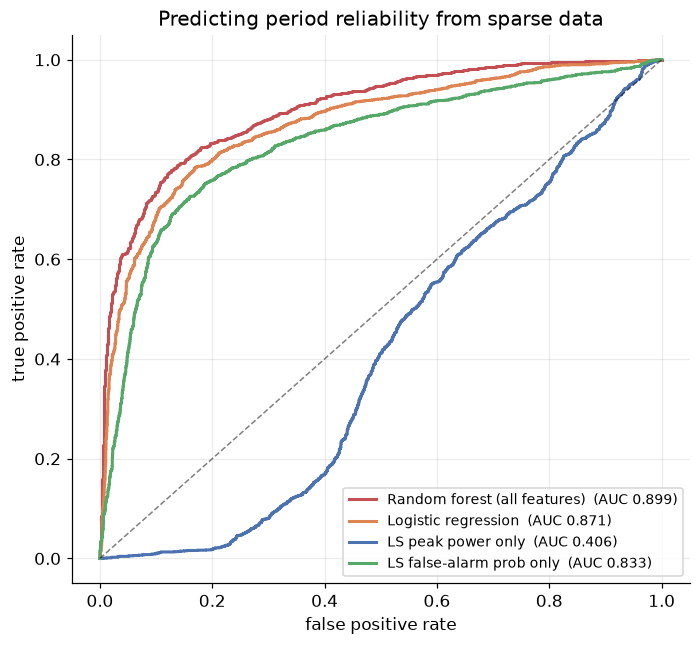

In [17]:
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                            n_jobs=-1, random_state=0,
                            class_weight="balanced_subsample").fit(Xtr, ytr)
logreg = make_pipeline(StandardScaler(),
                       LogisticRegression(max_iter=2000, class_weight="balanced")
                       ).fit(Xtr, ytr)

p_rf = rf.predict_proba(Xte)[:, 1]
p_lr = logreg.predict_proba(Xte)[:, 1]
p_pow = Xte["ls_top_power"].values          # naive: trust strong peaks
p_fap = -Xte["ls_fap"].values               # naive: trust low false-alarm prob

models = [
    ("Random forest (all features)", p_rf, RED),
    ("Logistic regression", p_lr, ORANGE),
    ("LS peak power only", p_pow, BLUE),
    ("LS false-alarm prob only", p_fap, GREEN),
]

fig, ax = plt.subplots(figsize=(6.5, 6))
print("ROC-AUC (predicting whether the LS period is correct):")
for name, p, c in models:
    auc = roc_auc_score(yte, p)
    fpr, tpr, _ = roc_curve(yte, p)
    ax.plot(fpr, tpr, color=c, lw=2, label=f"{name}  (AUC {auc:.3f})")
    print(f"  {name:<32} {auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("Predicting period reliability from sparse data")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(FIGDIR / "model_roc.png", bbox_inches="tight")
plt.show()

### 10.2 The payoff: a high-purity period catalog

The practical question is not the AUC but: *if we keep only the periods the model
is confident in, how trustworthy is that catalog, and how much do we keep?* The
left panel traces purity (fraction actually correct) against yield (fraction of
all objects kept) as the confidence threshold varies. Raw Lomb–Scargle sits at a
single point — it keeps everything, at the base-rate purity. The model lets us
trade yield for purity along the whole curve.

Operating point (purity >= 90%): threshold 0.71 -> purity 90%, yield 28% of objects (raw LS purity = 40%)


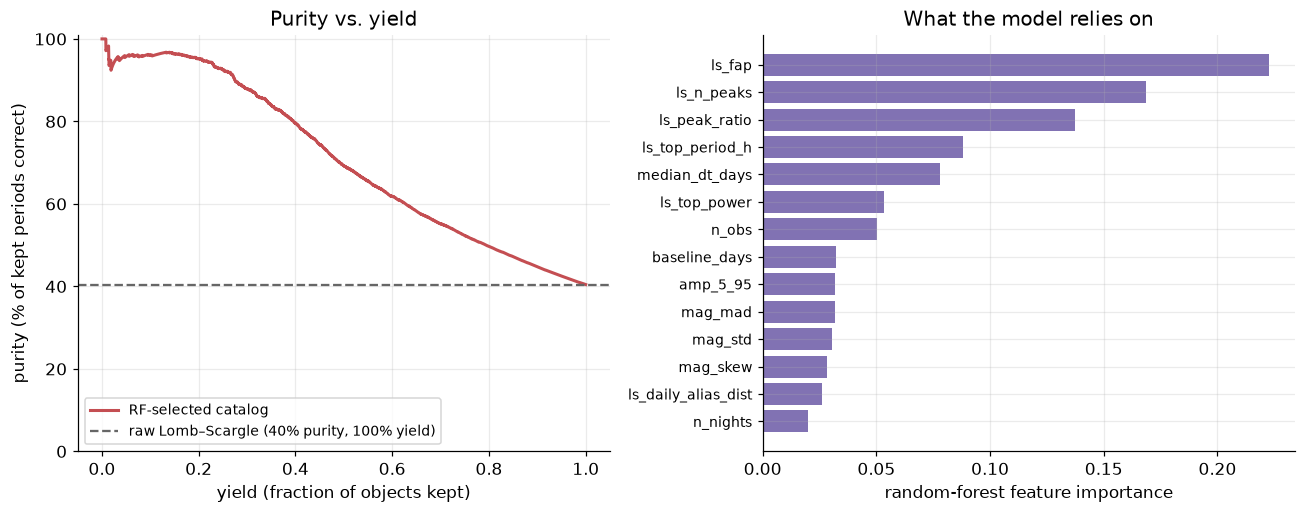

In [18]:
prec, rec, thr = precision_recall_curve(yte, p_rf)
base_rate = yte.mean()

# yield = fraction of all test objects kept at each threshold
yield_frac = [np.mean(p_rf >= t) for t in thr]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(yield_frac, prec[:-1] * 100, color=RED, lw=2, label="RF-selected catalog")
axes[0].axhline(base_rate * 100, ls="--", color="0.4",
                label=f"raw Lomb–Scargle ({base_rate*100:.0f}% purity, 100% yield)")
axes[0].set_xlabel("yield (fraction of objects kept)")
axes[0].set_ylabel("purity (% of kept periods correct)")
axes[0].set_ylim(0, 101)
axes[0].set_title("Purity vs. yield")
axes[0].legend(loc="lower left", fontsize=9)

# operating point: highest yield with purity >= 90%
ok = np.where(prec[:-1] >= 0.90)[0]
if ok.size:
    j = ok[np.argmax([yield_frac[i] for i in ok])]
    op_purity, op_yield, op_thr = prec[j] * 100, yield_frac[j] * 100, thr[j]
    print(f"Operating point (purity >= 90%): threshold {op_thr:.2f} -> "
          f"purity {op_purity:.0f}%, yield {op_yield:.0f}% of objects "
          f"(raw LS purity = {base_rate*100:.0f}%)")

# feature importances
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLUMNS).sort_values()
axes[1].barh(range(len(imp)), imp.values, color=PURPLE)
axes[1].set_yticks(range(len(imp)))
axes[1].set_yticklabels(imp.index, fontsize=9)
axes[1].set_xlabel("random-forest feature importance")
axes[1].set_title("What the model relies on")

fig.tight_layout()
fig.savefig(FIGDIR / "model_purity_importance.png", bbox_inches="tight")
plt.show()

### 10.3 What this baseline model establishes

The random forest predicts period reliability well above the raw periodogram
statistics, and its confidence score converts Lomb–Scargle's low-purity sparse
output into a catalog that is trustworthy at a chosen purity — exactly the
capability the Rubin-era use case needs: automatically flag the sparse-data
periods worth believing. The most informative features are the number of
observations, the periodogram peak strength and false-alarm probability, and the
lightcurve amplitude — matching the physical intuition from the EDA and baseline.

This is the **Unit 20 machine-learning baseline**. Unit 24 will build on it with
richer models (gradient-boosted trees, and the proposed CNN on the periodogram),
a candidate-ranking framing that can *recover* periods Lomb–Scargle misses rather
than only filtering them, and validation on real sparse survey data.

## 11. What the analysis tells us, and what comes next

**Findings so far**

- **~20,500 asteroids** have both a reliable period (U ≥ 2) and an ALCDEF light
  curve — a healthy supervised-learning dataset.
- Rotation periods span from minutes to hundreds of hours; the population piles up
  just above the 2.2 h spin barrier, exactly as physics predicts.
- Coverage is highly uneven: a large fraction of objects are *already* sparse
  (a substantial share have < 50 total points), so the pool of genuinely *dense*
  curves suitable as down-sampling sources is smaller than the full dataset and
  must be selected on an explicit density threshold (Section 6.1).
- Magnitude zero-points differ between sessions, so any period method (baseline or
  ML) must handle per-session offsets rather than treating a curve as one series.

- The **controlled-sparsity pipeline** (Section 8) turns the ~12,800 dense-pool
  curves into labeled sparse realizations at any observation count.
- The **Lomb–Scargle baseline** (Section 9) sets the reference: period recovery is
  reliable with hundreds of points but collapses in the sparse regime surveys
  actually deliver, and is strongly amplitude-dependent.
- The **baseline ML model** (Section 10) — a random forest on periodogram and curve
  features — predicts whether a sparse-data period is correct well above the raw
  periodogram statistics, and selects a high-purity catalog from Lomb–Scargle's
  otherwise low-purity sparse output. This is the Unit 20 machine-learning result.

**Unit 24 will extend this with:**

1. **Richer models** — gradient-boosted trees and the proposed CNN on the
   periodogram / phase-folded representation.
2. **A recovery-oriented framing** — ranking multiple periodogram candidates so the
   model can *recover* periods Lomb–Scargle misses, not only filter its top pick.
3. **Real sparse survey data** — validating on ZTF and Gaia DR3, where the sampling
   is genuinely sparse rather than simulated by down-sampling.